In [76]:
import pandas as pd
import seaborn as sns
import matplotlib as plt

In [77]:
df=pd.read_csv('/content/india_housing_prices.csv')
vizag_df=df[(df['State']=='Andhra Pradesh') & (df['City']=='Vishakhapatnam')]
vizag_df.drop(['State','City','ID'], axis=1,inplace=True)
vizag_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6118 entries, 37 to 249934
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Locality                        6118 non-null   object 
 1   Property_Type                   6118 non-null   object 
 2   BHK                             6118 non-null   int64  
 3   Size_in_SqFt                    6118 non-null   int64  
 4   Price_in_Lakhs                  6118 non-null   float64
 5   Price_per_SqFt                  6118 non-null   float64
 6   Year_Built                      6118 non-null   int64  
 7   Furnished_Status                6118 non-null   object 
 8   Floor_No                        6118 non-null   int64  
 9   Total_Floors                    6118 non-null   int64  
 10  Age_of_Property                 6118 non-null   int64  
 11  Nearby_Schools                  6118 non-null   int64  
 12  Nearby_Hospitals                6118

/tmp/ipython-input-468225581.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vizag_df.drop(['State','City','ID'], axis=1,inplace=True)


In [78]:
vizag_df.nunique()

,0
Locality,500
Property_Type,3
BHK,5
Size_in_SqFt,3340
Price_in_Lakhs,5778
Price_per_SqFt,87
Year_Built,34
Furnished_Status,3
Floor_No,31
Total_Floors,30


Step1) Convert all columns to numerical - One Hot Encoding, Label encoding (order makes sense)


Step2) convert them to datatype category - df.<column name>.astype("category"). Need our tree to know that it needs to treat these numerical values as categories

Step3)check for missing values if any, ? etc


Step4) sns.pairplot(df) - all pair of variables plotted
Check if any outliers present


Step5)boxplot for each col with price_in_lakhs - outliers


Step6) create a list of top outliers-their indices. of price_in-lakhs

drop or cap these outliers - I think this step could be skipped as random forest is spposed to be insensitive to outliers?


For re-usability : create these below steps as functions

step7) Start with all variables for now.
Split X_train, y_train, X_test, y_test


step8)build preliminary regression forest, with some parameters set randomly

n_estimators: number of trees in forest

max_features: at a time how many features will be picked to decide root/branch

max_samples: while bootstrapping how may records to be kept in one bag

oob_score: out of bag score. Sum of squares residuals found for out of bag records (testing done on these to understand good fit of model)

by default repitition is enabled fo bootstrapping

model=RandomForestRegressor(n_estimators=500, max_features=3, max_samples=60, oob_score=True)

rf=model.fit(X_train,y_train)

step9) rf.oob_score_
to know goodness of fit for the model

Step10) Inspect which variables were important
rf.feature_importances_
numpy array for scores (sum up to 1)

rf.feature_names_
Lists names of features

Step11) barplot these feature importance vs feature names

Step12) y_pred=rf.predict(X_test)

Evaluate performance by using base MAE, MSE, RMSE

step13) Reiterate - based on variable importance plot, remove variables which aren;t important. Feature enginnering - add new variables

Re-check model performance

Note: Decision forests are not sensitive to scale

Step14)scatter plot prediction vs true value

TP,FP,TN,FN matrix creation

Step15) Understand why some points have large deviation - decide what to do with these? delete from dataset? or something else?

Step16) how to improve performance by modifying parameters? Should I be doind cross validation? - Explore more on this

Step17) create pickle file for this model so that it can be used for any price prediction data.

with open("<nameOfFile>.pkl", wb) as f:
  pickle.dump(rf,f)

In [79]:
vizag_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6118 entries, 37 to 249934
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Locality                        6118 non-null   object 
 1   Property_Type                   6118 non-null   object 
 2   BHK                             6118 non-null   int64  
 3   Size_in_SqFt                    6118 non-null   int64  
 4   Price_in_Lakhs                  6118 non-null   float64
 5   Price_per_SqFt                  6118 non-null   float64
 6   Year_Built                      6118 non-null   int64  
 7   Furnished_Status                6118 non-null   object 
 8   Floor_No                        6118 non-null   int64  
 9   Total_Floors                    6118 non-null   int64  
 10  Age_of_Property                 6118 non-null   int64  
 11  Nearby_Schools                  6118 non-null   int64  
 12  Nearby_Hospitals                6118

In [80]:
pip install category_encoders

In [81]:
one_hot_encoding_list=['Owner_Type', 'Facing', 'Furnished_Status', 'Property_Type']
binary_encoding_list=['Parking_Space', 'Security', 'Availability_Status']
label_encoding_list=['Public_Transport_Accessibility']
frequency_encoding=['Location']

import category_encoders as ce

#Label encoding
vizag_df['Public_Transport_Accessibility']=vizag_df['Public_Transport_Accessibility'].replace({'Low':1,'Medium':2,'High':3})

frequency_encod_map=vizag_df['Locality'].value_counts().to_dict()
vizag_df['Locality_freq']=vizag_df['Locality'].replace(frequency_encod_map)
vizag_df.drop(['Locality'],axis=1,inplace=True)

#vizag_encoded=pd.get_dummies(vizag_df, columns=one_hot_encoding_list,dummy_na=True,dtype=int)
#vizag_encoded.nunique()
#verified that there were no nan values in dataset for categories so removing dummy_na
vizag_OneHotEncoded=pd.get_dummies(vizag_df, columns=one_hot_encoding_list,dtype=int)

#Initialize the BinaryEncoder
encoder = ce.BinaryEncoder(cols=binary_encoding_list)

# Apply binary encoding
vizag_encoded = encoder.fit_transform(vizag_OneHotEncoded)
#or use replace function directly for binary, label encoding


/tmp/ipython-input-425596588.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vizag_df['Public_Transport_Accessibility']=vizag_df['Public_Transport_Accessibility'].replace({'Low':1,'Medium':2,'High':3})
/tmp/ipython-input-425596588.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vizag_df['Public_Transport_Accessibility']=vizag_df['Public_Transport_Accessibility'].replace({'Low':1,'Medium':2,'High':3})
/tmp/ipython-input-425596588.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be r

In [82]:
vizag_encoded.dtypes

,0
BHK,int64
Size_in_SqFt,int64
Price_in_Lakhs,float64
Price_per_SqFt,float64
Year_Built,int64
Floor_No,int64
Total_Floors,int64
Age_of_Property,int64
Nearby_Schools,int64
Nearby_Hospitals,int64


In [83]:
#amenities to be created in One-Hot encoding format, no need of amenity score like it was done in linear regression

amenities = ['Pool', 'Gym', 'Clubhouse', 'Garden', 'Playground']

# Create new columns for each amenity and initialize with 0
for amenity in amenities:
    vizag_encoded[amenity] = 1
vizag_encoded.drop(['Amenities'],axis=1,inplace=True)

In [84]:
#convert data type to category

numerical_cols=['Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built',
       'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools',
       'Nearby_Hospitals', 'Locality_freq']

categorical_cols=['BHK', 'Public_Transport_Accessibility', 'Parking_Space_0',
       'Parking_Space_1', 'Security_0', 'Security_1', 'Availability_Status_0',
       'Availability_Status_1', 'Owner_Type_Broker',
       'Owner_Type_Builder', 'Owner_Type_Owner', 'Facing_East', 'Facing_North',
       'Facing_South', 'Facing_West', 'Furnished_Status_Furnished',
       'Furnished_Status_Semi-furnished', 'Furnished_Status_Unfurnished',
       'Property_Type_Apartment', 'Property_Type_Independent House',
       'Property_Type_Villa', 'Pool', 'Gym', 'Clubhouse', 'Garden',
       'Playground']
vizag_encoded[categorical_cols]=vizag_encoded[categorical_cols].astype('category')
vizag_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6118 entries, 37 to 249934
Data columns (total 36 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   BHK                              6118 non-null   category
 1   Size_in_SqFt                     6118 non-null   int64   
 2   Price_in_Lakhs                   6118 non-null   float64 
 3   Price_per_SqFt                   6118 non-null   float64 
 4   Year_Built                       6118 non-null   int64   
 5   Floor_No                         6118 non-null   int64   
 6   Total_Floors                     6118 non-null   int64   
 7   Age_of_Property                  6118 non-null   int64   
 8   Nearby_Schools                   6118 non-null   int64   
 9   Nearby_Hospitals                 6118 non-null   int64   
 10  Public_Transport_Accessibility   6118 non-null   category
 11  Parking_Space_0                  6118 non-null   category
 12  Parking_

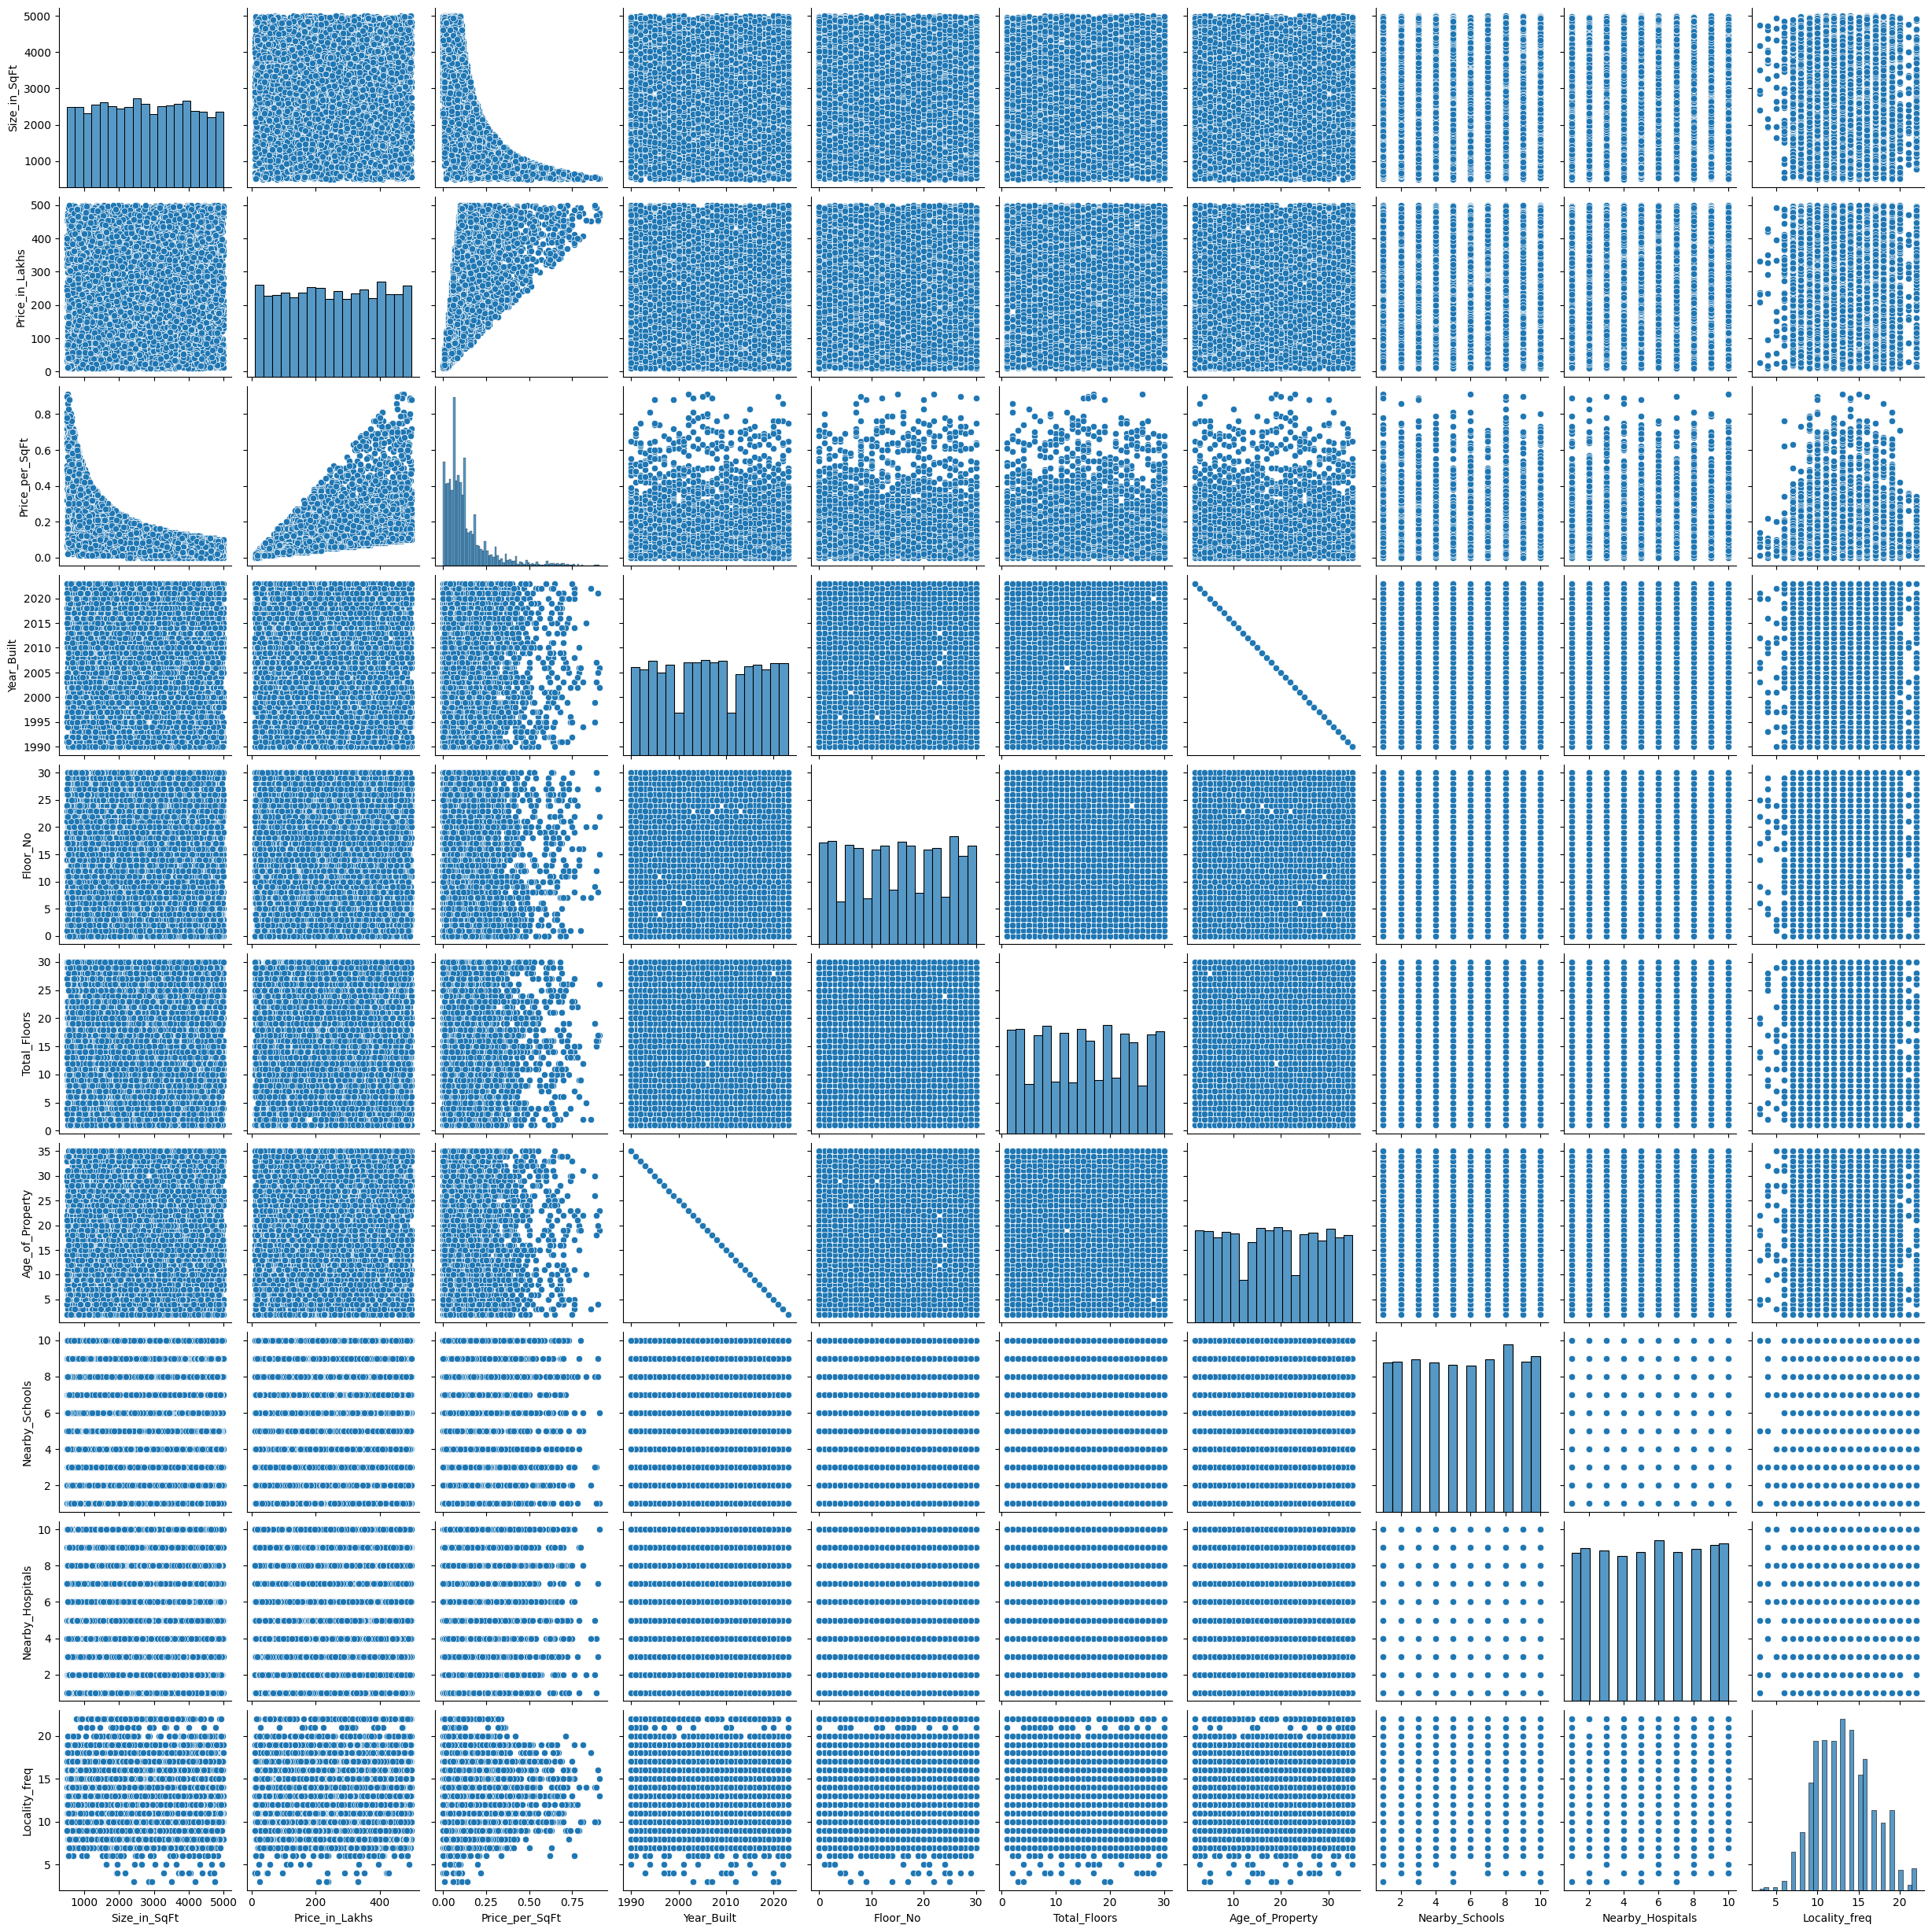

In [85]:
#check data
sns.pairplot(vizag_encoded)

Price per sq ft has some outliers in extreme end (very expensive)
some homes are small in size but have high price per sqft'

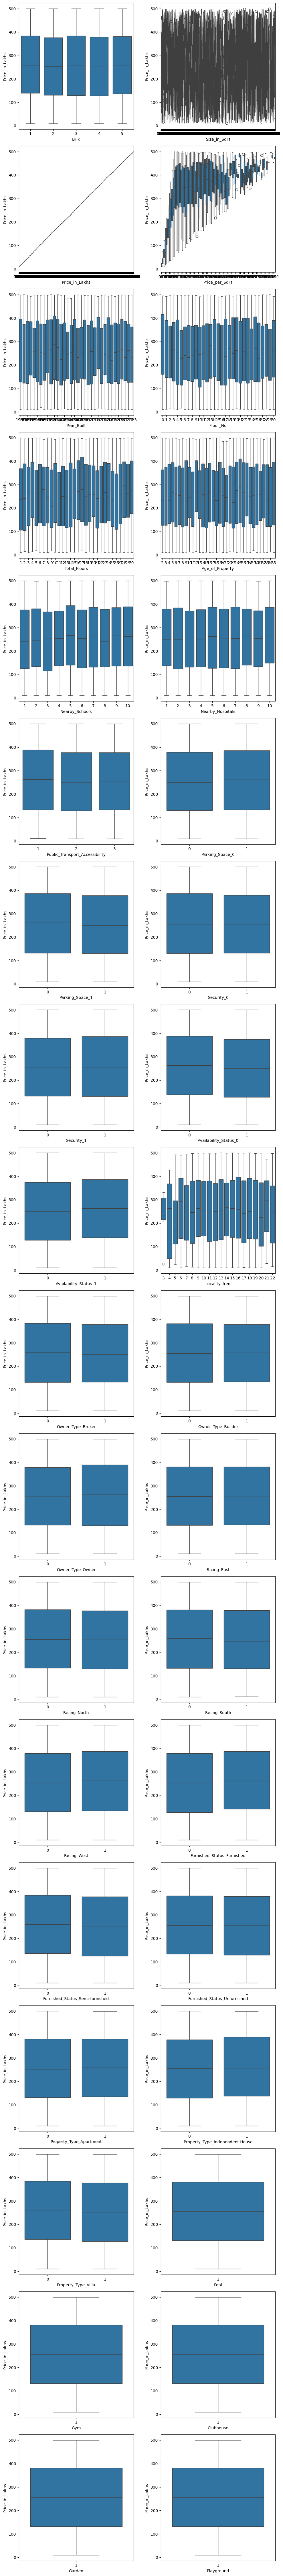

In [86]:
#boxplot for each column with Price_in_Lakhs
import matplotlib.pyplot as plt

# Determine the number of rows and columns for the subplots
n_features = len(vizag_encoded.columns)
n_cols = 2  # You can adjust this for desired layout
n_rows = (n_features + n_cols - 1) // n_cols # Calculate rows needed

# Create a figure and a set of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows))

# Flatten the axes array if there's more than one row/column
if n_rows > 1 or n_cols > 1:
    axes = axes.flatten()

# Loop through the features and plot histograms
for i, feature in enumerate(vizag_encoded.columns):
    if i < len(axes): # Ensure we don't try to plot more than available subplots
        sns.boxplot(x=vizag_encoded[feature],y=vizag_encoded["Price_in_Lakhs"] ,ax=axes[i])

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()


<Axes: ylabel='Price_per_SqFt'>

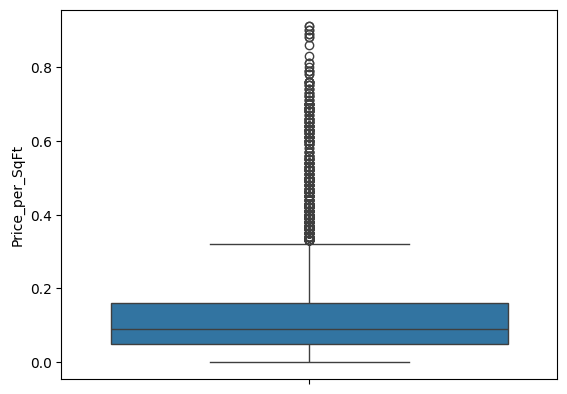

In [87]:
sns.boxplot(vizag_encoded["Price_per_SqFt"])

<Axes: ylabel='Size_in_SqFt'>

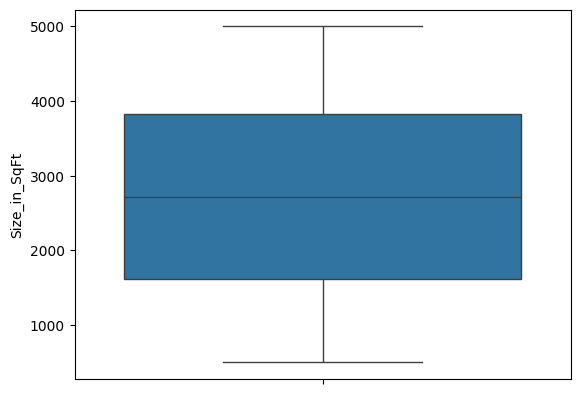

In [88]:
sns.boxplot(vizag_encoded["Size_in_SqFt"])

Price per sqft has lot of outliers (higher end) - what should I do with this?

Against Price_in_Lakhs - apart from price_per_sqft, no outliers found

I'm going to keep these outliers and go ahead with random forest as ideally random forest should be able to deal with outliers

In [107]:
#split data in train and test-let's build a baseline random forest first.
#later I'll check if it could be optimised

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

def split_Data_train_model(vizag_encoded,n_tree,f,s):
  X=vizag_encoded.drop(['Price_in_Lakhs'], axis=1,inplace=False)
  y=vizag_encoded['Price_in_Lakhs']
  X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2)
  model=RandomForestRegressor(n_estimators=n_tree, max_features=f, max_samples=s, oob_score=True)
  rf=model.fit(X_train,y_train)
  return rf,X_test,y_test,X_train,y_train


In [90]:
#baseline random forest
model=RandomForestRegressor(n_estimators=500, max_features=3, max_samples=60, oob_score=True)
rf=model.fit(X_train,y_train)

In [91]:
rf.oob_score_

0.3269244208911749

In [92]:
rf.ccp_alpha

0.0

Forget about setting alpha in random forest. It's difficult to set alpha for each decision tree in random forest

Rather focus on other parameters like number of trees, max depth

In [93]:
print("feature importance",rf.feature_importances_) #numpy array
print("feature names",rf.feature_names_in_) #numpy array


feature importance [0.03694082 0.06945927 0.21777555 0.06147731 0.05866267 0.060935
 0.05069742 0.04914287 0.04730626 0.0267005  0.01292088 0.01374189
 0.01400698 0.0145492  0.01302616 0.01426297 0.05263313 0.01465689
 0.01426509 0.01396473 0.01233812 0.01368514 0.01375284 0.01462666
 0.01567364 0.01448488 0.0148626  0.0149994  0.01460404 0.01384708
 0.         0.         0.         0.         0.        ]
feature names ['BHK' 'Size_in_SqFt' 'Price_per_SqFt' 'Year_Built' 'Floor_No'
 'Total_Floors' 'Age_of_Property' 'Nearby_Schools' 'Nearby_Hospitals'
 'Public_Transport_Accessibility' 'Parking_Space_0' 'Parking_Space_1'
 'Security_0' 'Security_1' 'Availability_Status_0' 'Availability_Status_1'
 'Locality_freq' 'Owner_Type_Broker' 'Owner_Type_Builder'
 'Owner_Type_Owner' 'Facing_East' 'Facing_North' 'Facing_South'
 'Facing_West' 'Furnished_Status_Furnished'
 'Furnished_Status_Semi-furnished' 'Furnished_Status_Unfurnished'
 'Property_Type_Apartment' 'Property_Type_Independent House'
 'Prop

Feature importance is displayed in the same order of columns as given in train dataset

In [94]:
def feature_importance_rf(rf):
  feature_name_list=list(rf.feature_names_in_)
  feature_importance_list=list(rf.feature_importances_)
  feature_name_importance_df=pd.DataFrame({"feature name": feature_name_list, "feature importance": feature_importance_list})
  print(feature_name_importance_df.sort_values(by="feature importance", ascending=False))
feature_importance_rf(rf)

                       feature name  feature importance
2                    Price_per_SqFt            0.217776
1                      Size_in_SqFt            0.069459
3                        Year_Built            0.061477
5                      Total_Floors            0.060935
4                          Floor_No            0.058663
16                    Locality_freq            0.052633
6                   Age_of_Property            0.050697
7                    Nearby_Schools            0.049143
8                  Nearby_Hospitals            0.047306
0                               BHK            0.036941
9    Public_Transport_Accessibility            0.026701
24       Furnished_Status_Furnished            0.015674
27          Property_Type_Apartment            0.014999
26     Furnished_Status_Unfurnished            0.014863
17                Owner_Type_Broker            0.014657
23                      Facing_West            0.014627
28  Property_Type_Independent House            0

<Axes: xlabel='feature importance', ylabel='feature name'>

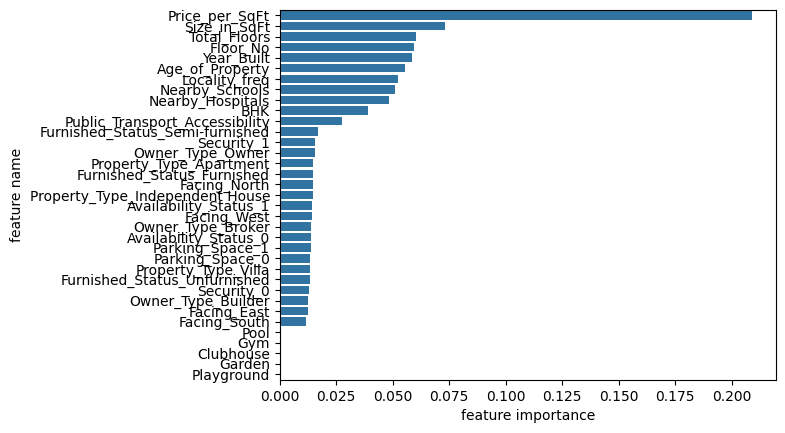

In [95]:
#sns.barplot(data=feature_name_importance_df, x="feature importance", y="feature name", sort=descending)

sns.barplot(data=feature_name_importance_df, x="feature importance", y="feature name", order=feature_name_importance_df.sort_values(by="feature importance", ascending=False)["feature name"])

OOB score still gets generated on training dataset (unused in bootstrapping)

It's a good idea to test on completely unseen data too

I'll use MAE, MSE, RMSE, R square

In [96]:
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model_unseen_test_Data(rf,X_test,y_test):
  y_pred=rf.predict(X_test)
  print("MAE",mean_absolute_error(y_test,y_pred))
  print("MSE",mean_squared_error(y_test,y_pred))
  print("RMSE", sqrt(mean_squared_error(y_test,y_pred)))
  print("R square", r2_score(y_test,y_pred))


In [97]:
#this is the baseline forest
rf,X_test,y_test=split_Data_train_model(vizag_encoded,500,3,60)
evaluate_model_unseen_test_Data(rf,X_test,y_test)

MAE 103.45605674836601
MSE 14282.373679987038
RMSE 119.5088853599892
R square 0.3238893329322172


Two things to do:
1) Will feature selection help in improving model?

2)Can max depth, number of trees, max features parameters be chosen for an optimized model?

Also want to check why are we getting such high error. It is because of some outliers?

Text(0, 0.5, 'actual')

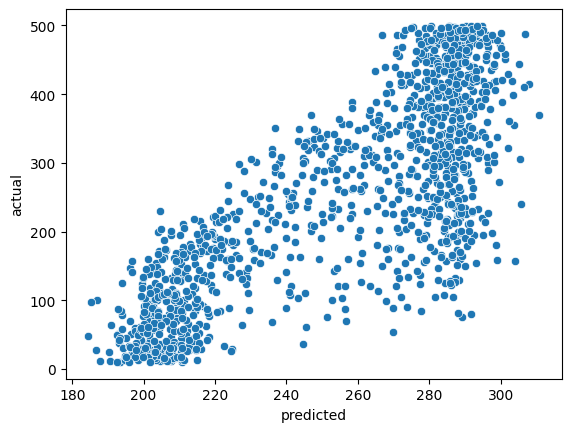

In [98]:
#scatter point for predicted and actual values
y_pred=rf.predict(X_test)
sns.scatterplot(x=y_pred,y=y_test)
plt.xlabel("predicted")
plt.ylabel("actual")

High end actual prices were not captured/predicted clearly by random forest- off by half the amount. If actual price is 500 lakhs, we're predicting 260 lakhs

For some cases actual price was around 100 lakhs but we predicted more than 250 lakhs

I'll check if feature enginnering helps first before I select feature

In [99]:
vizag_encoded_feature_engineered=vizag_encoded.copy()
vizag_encoded_feature_engineered["Hospital_school_nearby"]=vizag_encoded_feature_engineered["Nearby_Hospitals"]+vizag_encoded_feature_engineered["Nearby_Schools"]
vizag_encoded_feature_engineered["Floor_wrt_building"]=vizag_encoded_feature_engineered["Floor_No"]/vizag_encoded_feature_engineered["Total_Floors"]
vizag_encoded_feature_engineered["Price_total_area"]=vizag_encoded_feature_engineered["Price_per_SqFt"]*vizag_encoded_feature_engineered["Size_in_SqFt"]
vizag_encoded_feature_engineered.drop(["Nearby_Hospitals","Nearby_Schools","Floor_No","Total_Floors"],axis=1,inplace=True)

In [108]:
#building and evaluating random forest with feature engineering
rf2,X2_test,y2_test,X2_train,y2_train=split_Data_train_model(vizag_encoded_feature_engineered,500,3,60)
evaluate_model_unseen_test_Data(rf2,X2_test,y2_test)

MAE 69.30711207516339
MSE 7121.099193213431
RMSE 84.38660553200035
R square 0.6628955918912947


Any further improvement could happen if we select features using feature importance?

In [101]:
feature_importance_rf(rf2)

                       feature name  feature importance
33                 Price_total_area            0.249696
2                    Price_per_SqFt            0.178399
1                      Size_in_SqFt            0.056849
32               Floor_wrt_building            0.053362
3                        Year_Built            0.050196
4                   Age_of_Property            0.047856
31           Hospital_school_nearby            0.043431
12                    Locality_freq            0.041886
0                               BHK            0.032146
5    Public_Transport_Accessibility            0.023895
24  Property_Type_Independent House            0.013495
8                        Security_0            0.012614
23          Property_Type_Apartment            0.012381
21  Furnished_Status_Semi-furnished            0.012340
7                   Parking_Space_1            0.012045
25              Property_Type_Villa            0.012026
6                   Parking_Space_0            0

In [109]:
 #drop features with importance less than 0.01
vizag_encoded_feature_engineered_selection=vizag_encoded_feature_engineered.copy()
vizag_encoded_feature_engineered_selection.drop(["Facing_East","Facing_West","Pool","Gym","Clubhouse","Garden","Playground"],axis=1,inplace=True)
rf3,X3_test,y3_test,X3_train,y3_train=split_Data_train_model(vizag_encoded_feature_engineered_selection,500,3,60)
evaluate_model_unseen_test_Data(rf3,X3_test,y3_test)


MAE 62.63700249999999
MSE 5963.987191084653
RMSE 77.22685537482835
R square 0.7176719046499829


Improvement baby!!

Now let's see if we can optimise further by changing n_tree, max_depth, max features

Methods:

Grid Search

Randomised search

Bayesian optimization

In [116]:
#Grid search
n_trees=[20,60,150,500]
max_depth=[10,50,100]
max_features=[3,7,10]
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': n_trees,
    'max_depth': max_depth,
    'max_features': max_features
}

rf2_grid=GridSearchCV(estimator=RandomForestRegressor(), param_grid=param_grid, cv=5, verbose=2, n_jobs=-1)
#verbose=2 will show me what's going on behidn the scene
#n_job=-1 will ensure all resources allocated

In [117]:
rf2_grid.fit(X3_train,y3_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_depth': [10, 50, 100], 'max_features': [3, 7, 10],
                         'n_estimators': [20, 60, 150, 500]},
             verbose=2)

In [118]:
print("best values of parameters as per given list",rf2_grid.best_params_)
print("best score",rf2_grid.best_score_)

best values of parameters as per given list {'max_depth': 100, 'max_features': 10, 'n_estimators': 500}
best score 0.9956118197378885


Seems like it just picked highest value of each parameter! Perhaps reduce if it takes too much time to run on huge datasets, I could decrease the highest value of parameter and check performance of model if there's significant difference

Check performance by test dataset using these parameters

In [112]:
model1=RandomForestRegressor(n_estimators=500, max_features=10,max_depth=50,oob_score=True)
best_param_rf=model1.fit(X3_train,y3_train)
evaluate_model_unseen_test_Data(best_param_rf,X3_test,y3_test)

MAE 7.609885947712401
MSE 90.35439144192117
RMSE 9.505492698535997
R square 0.9957227300420026


Repeat testing using cross validation and find average score of this model with these parameters

In [114]:
from sklearn.model_selection import cross_val_score
cross_val_score(best_param_rf,X3_train,y3_train,cv=5)

array([0.99558478, 0.99564322, 0.99594492, 0.99550049, 0.99551347])

All 5 folds almost gave similar performance so I'm satisfied. If one of the fold had given lesser score, then I would have been worried. BTW what's the default score mechanism that cross val score picks? what's this score we're referring to? - think it's R square

Let's repeat the same using Randomised search for hyperparameter tuning

In [122]:
n_trees=[20,60,150,500,1000]
max_depth=[10,50,100,None]
max_features=[3,7,10]
sample_percentage=[0.3,0.5,0.75]
min_items_inLeaf=[1,2,5]
bootstrap=[True,False]
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'n_estimators': n_trees,
    'max_depth': max_depth,
    'max_features': max_features,
    'min_samples_leaf':min_items_inLeaf,
   # 'bootstrap':bootstrap,
    'max_samples':sample_percentage
}

rf2_random=RandomizedSearchCV(estimator=RandomForestRegressor(), param_distributions=param_grid, cv=5, verbose=2, n_jobs=-1)
rf2_random.fit(X3_train,y3_train)
print("best values of parameters as per given list using Random search CV",rf2_random.best_params_)
print("best score using Random search CV",rf2_random.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
best values of parameters as per given list using Random search CV {'n_estimators': 60, 'min_samples_leaf': 1, 'max_samples': 0.5, 'max_features': 10, 'max_depth': None}
best score using Random search CV 0.9949058260272


In [123]:
model3=RandomForestRegressor(n_estimators=60, max_samples=0.5 , max_features= 10, min_samples_leaf=1, oob_score=True)
best_param_rf_randomS=model3.fit(X3_train,y3_train)
evaluate_model_unseen_test_Data(best_param_rf_randomS,X3_test,y3_test)

MAE 7.868440359477125
MSE 96.14512438825356
RMSE 9.805362022294412
R square 0.9954486035975558


In [124]:
cross_val_score(best_param_rf_randomS, X3_train, y3_train, cv=5)

array([0.99497678, 0.99513472, 0.99524007, 0.99480004, 0.99460973])

Touch base on last optimized method -Naive Bayesian